In [1]:
# ============================================
# Blockwise permutation + Areal GP + VI module
# Using meuse_obs.zip (geopandas) & elev as X
# ============================================

import os
from typing import Dict, Any, Sequence

import numpy as np
import torch
import torch.optim as optim
from tqdm import tqdm

import pandas as pd
import geopandas as gpd  # <--- NEW

from GPModel import GPModel
from GPArealModel import GPArealModel
from VIGP_Unlinked import VIGP_Unlinked

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def _to_tensor(x, dtype=torch.float32):
    if isinstance(x, torch.Tensor):
        return x.to(device=device, dtype=dtype)
    return torch.as_tensor(x, device=device, dtype=dtype)


# ---------------------------------------------------------
# STEP 2 helper: construct blockwise permutation at data level
# ---------------------------------------------------------

def make_blockwise_permuted_data(
    coords,
    X,
    Y,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
) -> Dict[str, torch.Tensor]:
    """
    Prepare original (restricted) and blockwise-permuted data.

    Inputs
    ------
    coords : array-like (N, d)
    X      : array-like (N,) or (N, 1)
    Y      : array-like (N,)
    n_blocks, n_locations : define N_use = n_blocks * n_locations
    seed : for reproducible permutations

    Returns a dict with:
        coords_orig, X_orig, Y_orig   : restricted, sorted (unpermuted)
        coords_perm, X_perm, Y_perm   : permuted inside blocks
        region_assignments            : (N_use,) with values 0,...,B-1
        perm_matrix_x, perm_matrix_s  : (N_use, N_use) block-diagonal perms
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords = _to_tensor(coords)
    Y = _to_tensor(Y).view(-1)  # (N,)
    X = _to_tensor(X)

    if X.ndim == 1:
        X = X.unsqueeze(1)  # (N, 1)

    N_total = coords.shape[0]
    N_use = n_blocks * n_locations
    if N_total < N_use:
        raise ValueError(f"Not enough locations: N={N_total}, required N_use={N_use}.")

    # Sort by first coordinate (x), then restrict to N_use
    sort_idx = torch.argsort(coords[:, 0])
    sort_idx = sort_idx[:N_use]

    coords_orig = coords[sort_idx].contiguous()  # (N_use, d)
    X_orig = X[sort_idx].contiguous()            # (N_use, 1)
    Y_orig = Y[sort_idx].contiguous()            # (N_use,)

    N = N_use

    # Region assignments: fixed blocks
    region_assignments = torch.zeros(N, dtype=torch.long, device=device)
    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations
        region_assignments[start:end] = b

    # Blockwise permutation matrices
    #   - perm_matrix_x: permutes X,Y jointly within block
    #   - perm_matrix_s: independent perm for coordinates
    perm_matrix_x = torch.zeros(N, N, device=device)
    perm_matrix_s = torch.zeros(N, N, device=device)

    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations

        # X,Y permutation
        perm_xy = torch.randperm(n_locations, device=device)
        for i in range(n_locations):
            perm_matrix_x[start + i, start + perm_xy[i]] = 1.0

        # S permutation
        perm_s = torch.randperm(n_locations, device=device)
        for i in range(n_locations):
            perm_matrix_s[start + i, start + perm_s[i]] = 1.0

    # Apply permutations
    Y_perm = (perm_matrix_x @ Y_orig.view(N, 1)).view(N)
    X_perm = perm_matrix_x @ X_orig                  # (N, 1)
    coords_perm = perm_matrix_s @ coords_orig        # (N, d)

    return {
        "coords_orig": coords_orig,
        "X_orig": X_orig,
        "Y_orig": Y_orig,
        "coords_perm": coords_perm,
        "X_perm": X_perm,
        "Y_perm": Y_perm,
        "region_assignments": region_assignments,
        "perm_matrix_x": perm_matrix_x,
        "perm_matrix_s": perm_matrix_s,
    }


# ---------------------------------------------------------
# STEP 3a: Areal GP ONLY (disentangled)
# ---------------------------------------------------------

def run_areal_gp(
    coords_perm: torch.Tensor,
    X_perm: torch.Tensor,
    Y_perm: torch.Tensor,
    region_assignments: torch.Tensor,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
    niter_GPAreal: int = 3000,
) -> Dict[str, Any]:
    """
    Run GPArealModel (areal GP) on block-averaged data,
    using permuted coordinates and block structure.
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords_perm = _to_tensor(coords_perm)
    Y_perm = _to_tensor(Y_perm).view(-1)
    X_perm = _to_tensor(X_perm)

    if X_perm.ndim == 1:
        X_perm = X_perm.unsqueeze(1)
    p = X_perm.shape[1]
    if p != 1:
        raise ValueError(f"GPArealModel wrapper assumes scalar X (p=1), got p={p}.")

    region_assignments = region_assignments.to(device=device, dtype=torch.long)

    N = coords_perm.shape[0]
    assert N == n_blocks * n_locations, "N must equal n_blocks * n_locations."

    # Block averages of X and Y
    ybar = torch.zeros(n_blocks, device=device)
    xbar = torch.zeros(n_blocks, p, device=device)

    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations
        idx = torch.arange(start, end, device=device)
        ybar[b] = Y_perm[idx].mean()
        xbar[b] = X_perm[idx].mean(dim=0)

    gpa = GPArealModel().to(device)
    opt_gpa = optim.AdamW(gpa.parameters(), lr=0.01, weight_decay=0.01)

    for _ in tqdm(range(niter_GPAreal), desc="Train GPArealModel (areal)"):
        opt_gpa.zero_grad()
        loss = gpa(coords_perm, region_assignments, xbar, ybar)
        loss.backward()
        opt_gpa.step()
        with torch.no_grad():
            gpa.sigmasq.clamp_(min=1e-6)
            gpa.phi.clamp_(min=1e-6)
            gpa.tausq.clamp_(min=1e-6)

    return {
        "nu": float(gpa.nu.item()),
        "phi": float(gpa.phi.item()),
        "sigmasq": float(gpa.sigmasq.item()),
        "tausq": float(gpa.tausq.item()),
        "beta": gpa.beta.detach().cpu().numpy(),
    }


# ---------------------------------------------------------
# STEP 3b: VI for Unlinked GP ONLY (disentangled)
# ---------------------------------------------------------

def run_vi_unlinked(
    coords_perm: torch.Tensor,
    X_perm: torch.Tensor,
    Y_perm: torch.Tensor,
    perm_matrix_x: torch.Tensor,
    perm_matrix_s: torch.Tensor,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
    niter_VI: int = 100,
    phi_prior_ub: float = 0.5,
    phi_prior_lb: float = 0.0,
    tau_grid: Sequence[float] = (0.2, 0.4, 0.6, 0.8, 0.9),
) -> Dict[str, Any]:
    """
    Run VIGP_Unlinked (VI for unlinked GP) on blockwise permuted X,Y,S.

    Returns a dict with VI outputs for each tau:
        {
          "by_tau": { tau_value: vi_out, ... },
          "taus": [...],
          "prior_parameters": {...}
        }
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords_perm = _to_tensor(coords_perm)
    Y_perm = _to_tensor(Y_perm).view(-1)  # (N,)
    X_perm = _to_tensor(X_perm)

    if X_perm.ndim == 1:
        X_perm = X_perm.unsqueeze(1)
    p = X_perm.shape[1]
    if p != 1:
        raise ValueError(f"VI wrapper assumes scalar X (p=1), got p={p}.")

    perm_matrix_x = perm_matrix_x.to(device=device)
    perm_matrix_s = perm_matrix_s.to(device=device)

    N = coords_perm.shape[0]
    assert N == n_blocks * n_locations, "N must equal n_blocks * n_locations."

    # Distances from permuted coordinates
    Dist = torch.cdist(coords_perm, coords_perm, p=2)
    Dist = (Dist + Dist.T) / 2.0

    # Block-shaped tensors for VI
    X_blocks = X_perm.view(n_blocks, n_locations)  # (B, n_i)
    Y_blocks = Y_perm.view(n_blocks, n_locations)  # (B, n_i)

    n_steps = 50
    n_phi_samples = 100
    n_piX_sample = 50
    n_piS_sample = 50

    prior_parameters = {
        "a1": 0.1,
        "b1": 0.1,
        "a2": 0.1,
        "b2": 0.1,
        "eta_X_sq": 0.1,
        "eta_S_sq": 0.1,
        "mu_beta": 0.0,
        "sigmasq_beta": 100.0,
        "phi_prior_lb": phi_prior_lb,
        "phi_prior_ub": phi_prior_ub,
    }


    vi_results_by_tau: Dict[float, Any] = {}

    for tau in tau_grid:
        vi_out = VIGP_Unlinked(
            n_iter=niter_VI,
            n_blocks=n_blocks,
            n_locations=n_locations,
            X=X_blocks,
            Y=Y_blocks,
            Dist=Dist,
            n_steps=n_steps,
            n_phi_samples=n_phi_samples,
            n_piX_sample=n_piX_sample,
            tau_X=tau,
            tau_S=tau,
            n_piS_sample=n_piS_sample,
            seed=seed,
            fix_piX=False,
            fix_piS=False,
            fix_mu_lambda_beta=False,
            fix_sigmasq_lambda_beta=False,
            fix_lambda_b1=False,
            lambda_b1_fixed=((n_blocks * n_locations) * 0.5 + 0.1) * 5,
            fix_lambda_b2=False,
            M_X_star_fixed=perm_matrix_x.T,
            M_S_star_fixed=perm_matrix_s.T,
            V_X_star_fixed=torch.eye(n_locations, n_locations, device=device),
            V_S_star_fixed=torch.eye(n_locations, n_locations, device=device),
            phi_init=0.05,
            mean_Rphi_inv_fixed=None,
            fix_mean_Rphi_inv=False,
            pi_X_true=None,
            pi_S_true=None,
            VX_ub=0.5,
            VS_ub=0.5,
            lr_piS=0.01,
            lr_piX=0.01,
            prior_parameters=prior_parameters,
        )
        vi_results_by_tau[float(tau)] = vi_out

    return {
        "by_tau": vi_results_by_tau,
        "taus": list(map(float, tau_grid)),
        "prior_parameters": prior_parameters,
    }


# ============================================================
# Demo: FULL PIPELINE on meuse_obs.zip
# ============================================================


# __file__ is not defined in interactive environments (e.g., Jupyter notebooks).
# Fall back to the current working directory when needed.
try:
    base_dir = os.path.dirname(__file__)
except NameError:
    base_dir = os.getcwd()

MEUSE_OBS_PATH = os.path.abspath(os.path.join(
    base_dir,
    "..",
    "data", "data_analysis",
    "meuse_obs.zip",
))

meuse_obs = gpd.read_file(MEUSE_OBS_PATH)

# coords from geometry (x, y)
coords_meuse = np.column_stack(
    [meuse_obs.geometry.x.to_numpy(), meuse_obs.geometry.y.to_numpy()]
)

# response: log1p(zinc)
Y_meuse = np.log1p(meuse_obs["zinc"].to_numpy())

# scalar covariate: elevation
# (column name in this dataset is 'elev'; if it's 'elevation' on your side, change here)
X_meuse = meuse_obs["elev"].to_numpy()

# center covariate and response to zero mean
X_meuse_mean = X_meuse.mean()
Y_meuse_mean = Y_meuse.mean()

X_meuse = X_meuse - X_meuse_mean
Y_meuse = Y_meuse - Y_meuse_mean

print(f"Centered X_meuse mean: {X_meuse.mean():.6f}, Y_meuse mean: {Y_meuse.mean():.6f}")

N_meuse = coords_meuse.shape[0]
print(f"Loaded meuse_obs: N = {N_meuse}")

# Rescale coordinates for numerical stability (e.g. to km)
coords_center = coords_meuse.mean(axis=0)
coords_scaled = (coords_meuse) / 1000.0  # now roughly in km
# Normalize coordinates to [0, 1] range
coords_min = coords_meuse.min(axis=0)
coords_max = coords_meuse.max(axis=0)
coords_scaled = (coords_meuse - coords_min) / (coords_max - coords_min)

print(f"Coordinates normalized to [0, 1]: min={coords_scaled.min():.6f}, max={coords_scaled.max():.6f}")


Centered X_meuse mean: -0.000000, Y_meuse mean: 0.000000
Loaded meuse_obs: N = 155
Coordinates normalized to [0, 1]: min=0.000000, max=1.000000


In [2]:
coords_perm_data = make_blockwise_permuted_data(
    coords=coords_scaled,
    X=X_meuse,
    Y=Y_meuse,
    n_blocks=5,
    n_locations=31,
    seed=2029,
)
coords_perm = coords_perm_data["coords_perm"]
X_perm = coords_perm_data["X_perm"]
Y_perm = coords_perm_data["Y_perm"]
region_assignments = coords_perm_data["region_assignments"]
perm_matrix_x = coords_perm_data["perm_matrix_x"]
perm_matrix_s = coords_perm_data["perm_matrix_s"]
n_blocks_demo = 5
n_locations_demo = 31

# -----------------------------
# STEP 3a: Areal GP on permuted data
# -----------------------------
areal_results = run_areal_gp(
    coords_perm=coords_perm,
    X_perm=X_perm,
    Y_perm=Y_perm,
    region_assignments=region_assignments,
    n_blocks=n_blocks_demo,
    n_locations=n_locations_demo,
    seed=2030,
    niter_GPAreal=1000,   # shorter for demo
)


Train GPArealModel (areal):   0%|          | 0/1000 [00:00<?, ?it/s]/Users/debangandey/Documents/GitHub/SpatialReg-Unlinked/src/GPArealModel.py:26: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729646995093/work/aten/src/ATen/native/TensorShape.cpp:3687.)
  quadratic_term = residual.T @ torch.linalg.solve(K_NN_noise, residual)
Train GPArealModel (areal): 100%|██████████| 1000/1000 [00:00<00:00, 2367.56it/s]


In [3]:
areal_results

{'nu': 0.5,
 'phi': 1.731647253036499,
 'sigmasq': 9.999999974752427e-07,
 'tausq': 0.3998256325721741,
 'beta': array([-0.2226098], dtype=float32)}

In [ ]:
# -----------------------------
# STEP 3b: VI unlinked on permuted data
# -----------------------------
vi_results = run_vi_unlinked(
    coords_perm=coords_perm,
    X_perm=X_perm,
    Y_perm=Y_perm,
    perm_matrix_x=perm_matrix_x,
    perm_matrix_s=perm_matrix_s,
    n_blocks=n_blocks_demo,
    n_locations=n_locations_demo,
    seed=2025,
    niter_VI=50,
    phi_prior_lb=0.01, 
    phi_prior_ub=2,
    tau_grid= (0.1,0.15,0.25,0.35)
)


  0%|          | 0/50 [00:00<?, ?it/s]

Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: -4.3176e-07
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: -4.3176e-07


  2%|▏         | 1/50 [00:20<16:51, 20.65s/it]

Iter 1/50 | mu_lambda_beta: -0.0397 | 
 sigmasq_lambda_beta: 0.0000 | 
 lambda_a1: 77.6000 | lambda_b1: 138.1775 | lambda_a2: 77.6000 | lambda_b2: 117.3623
‣  E[ϕ]: 0.0832 | ‣ ||mu_W||: 1.4385
Total Loss: 1.0714
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 2.9200e-02
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 2.9223e-02


  4%|▍         | 2/50 [00:41<16:34, 20.72s/it]

...

Iter 3/50 | mu_lambda_beta: -0.0416 | 
 sigmasq_lambda_beta: 0.0065 | 
 lambda_a1: 77.6000 | lambda_b1: 129.3579 | lambda_a2: 77.6000 | lambda_b2: 74.9558
‣  E[ϕ]: 0.2387 | ‣ ||mu_W||: 1.5383
Total Loss: 0.9214
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 1.2430e-01
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 1.2400e-01


  8%|▊         | 4/50 [01:23<15:56, 20.80s/it]

Iter 4/50 | mu_lambda_beta: -0.0585 | 
 sigmasq_lambda_beta: 0.0051 | 
 lambda_a1: 77.6000 | lambda_b1: 118.6249 | lambda_a2: 77.6000 | lambda_b2: 65.7385
‣  E[ϕ]: 0.3634 | ‣ ||mu_W||: 1.4994
Total Loss: 0.8753
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 1.5624e-01
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 1.5627e-01


 10%|█         | 5/50 [01:44<15:39, 20.87s/it]

Iter 5/50 | mu_lambda_beta: -0.0703 | 
 sigmasq_lambda_beta: 0.0043 | 
 lambda_a1: 77.6000 | lambda_b1: 123.5534 | lambda_a2: 77.6000 | lambda_b2: 59.3828
‣  E[ϕ]: 0.4924 | ‣ ||mu_W||: 1.4538
Total Loss: 0.8422
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 1.8507e-01
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 1.8550e-01


In [11]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

# You already have these prepared:
# meuse_obs, coords_meuse, X_meuse, Y_meuse, X_meuse_mean, Y_meuse_mean

N_meuse = coords_meuse.shape[0]

# ----------------------------------------
# 0. Design matrix (centered scale)
# ----------------------------------------
X_design = np.column_stack([
    np.ones(N_meuse),   # intercept
    X_meuse             # centered elevation
])

# ----------------------------------------
# 1. OLS: beta_hat_OLS
# ----------------------------------------
XtX = X_design.T @ X_design
XtY = X_design.T @ Y_meuse
beta_hat_OLS = np.linalg.solve(XtX, XtY)

beta0_OLS, beta1_OLS = beta_hat_OLS
print(f"OLS beta0_hat (centered): {beta0_OLS:.4f}")
print(f"OLS beta1_hat (centered): {beta1_OLS:.4f}")

Y_hat_fixed_OLS = X_design @ beta_hat_OLS
residuals = Y_meuse - Y_hat_fixed_OLS

# ----------------------------------------
# 2. Fit spatial GP on residuals
#    w(s) ~ GP(0, sigma^2 * exp(-d/phi)),
#    implemented as Matern(nu=0.5) + WhiteKernel
# ----------------------------------------
spatial_kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=1.0,
    length_scale_bounds=(1e-2, 1e3),
    nu=0.5
)
nugget_kernel = WhiteKernel(
    noise_level=0.1,
    noise_level_bounds=(1e-6, 1e2)
)
kernel = spatial_kernel + nugget_kernel

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0,
    normalize_y=False,      # residuals already ~ mean 0
    n_restarts_optimizer=5,
    random_state=2025
)

gp.fit(coords_scaled, residuals)

print("\nFitted kernel (residual GP):")
print(gp.kernel_)

k_spatial, k_nugget = gp.kernel_.k1, gp.kernel_.k2
sigma2_hat = float(k_spatial.k1.constant_value)     # partial sill
phi_hat_scaled = float(k_spatial.k2.length_scale)   # range on scaled coords
tausq_hat = float(k_nugget.noise_level)             # nugget

phi_hat_original = phi_hat_scaled * 1000.0

print("\nEstimated covariance parameters:")
print(f"sigma^2 (partial sill): {sigma2_hat:.4f}")
print(f"phi (scaled units):     {phi_hat_scaled:.4f}")
print(f"phi (original units):   {phi_hat_original:.2f}")
print(f"tau^2 (nugget):         {tausq_hat:.4f}")

# --------------------------------------------------
# 3. GLS estimate of beta using Σ̂ from the GP
#    Σ̂ = Cov(w + e) at observed locations
# --------------------------------------------------

# Covariance matrix at training locations (includes nugget)
Sigma_hat = gp.kernel_(coords_scaled)

# Add a tiny jitter on the diagonal for numerical stability
Sigma_hat = Sigma_hat + 1e-8 * np.eye(N_meuse)

# Cholesky-based solve for Σ^{-1} X and Σ^{-1} Y
L = np.linalg.cholesky(Sigma_hat)

# Solve L * Z = X_design -> Z
Z = np.linalg.solve(L, X_design)
# Then L^T * (Σ^{-1} X) = Z -> Σ^{-1} X
Sigma_inv_X = np.linalg.solve(L.T, Z)

# Similarly for Y
z_y = np.linalg.solve(L, Y_meuse)
Sigma_inv_Y = np.linalg.solve(L.T, z_y)

# GLS: beta_GLS = (X^T Σ^{-1} X)^{-1} X^T Σ^{-1} Y
Xt_Sinv_X = X_design.T @ Sigma_inv_X
Xt_Sinv_Y = X_design.T @ Sigma_inv_Y
beta_hat_GLS = np.linalg.solve(Xt_Sinv_X, Xt_Sinv_Y)

beta0_GLS, beta1_GLS = beta_hat_GLS

print("\nGLS beta estimates (centered scale):")
print(f"beta0_GLS (centered): {beta0_GLS:.4f}")
print(f"beta1_GLS (centered): {beta1_GLS:.4f}")

# ----------------------------------------
# 4. Transform β back to ORIGINAL scale
# ----------------------------------------
# Recall:
#   X_meuse = X_orig - X_meuse_mean
#   Y_meuse = Y_orig - Y_meuse_mean
#
# Model on centered scale:
#   Y_meuse = beta0 + beta1 * X_meuse + ...
# => Y_orig - Y_mean = beta0 + beta1 * (X_orig - X_mean) + ...
# => Y_orig = (beta0 + Y_mean - beta1 * X_mean) + beta1 * X_orig + ...

def transform_beta_to_original(beta0_centered, beta1_centered,
                               X_mean, Y_mean):
    beta1_orig = beta1_centered
    beta0_orig = beta0_centered + Y_mean - beta1_centered * X_mean
    return beta0_orig, beta1_orig

beta0_OLS_orig, beta1_OLS_orig = transform_beta_to_original(
    beta0_OLS, beta1_OLS, X_meuse_mean, Y_meuse_mean
)
beta0_GLS_orig, beta1_GLS_orig = transform_beta_to_original(
    beta0_GLS, beta1_GLS, X_meuse_mean, Y_meuse_mean
)

print("\nFixed-effect coefficients on ORIGINAL scale:")
print("OLS:")
print(f"  beta0_OLS_orig: {beta0_OLS_orig:.4f}")
print(f"  beta1_OLS_orig: {beta1_OLS_orig:.4f}")
print("GLS:")
print(f"  beta0_GLS_orig: {beta0_GLS_orig:.4f}")
print(f"  beta1_GLS_orig: {beta1_GLS_orig:.4f}")

# ----------------------------------------
# 5. Optional: fitted values using GLS β
# ----------------------------------------
Y_hat_fixed_GLS = X_design @ beta_hat_GLS
w_hat_GLS, w_std_GLS = gp.predict(coords_scaled, return_std=True)
Y_hat_full_GLS_centered = Y_hat_fixed_GLS + w_hat_GLS
Y_hat_full_GLS = Y_hat_full_GLS_centered + Y_meuse_mean  # back to original log1p(zinc)


OLS beta0_hat (centered): 0.0000
OLS beta1_hat (centered): -0.4533

Fitted kernel (residual GP):
0.671**2 * Matern(length_scale=0.213, nu=0.5) + WhiteKernel(noise_level=0.0343)

Estimated covariance parameters:
sigma^2 (partial sill): 0.4501
phi (scaled units):     0.2130
phi (original units):   212.98
tau^2 (nugget):         0.0343

GLS beta estimates (centered scale):
beta0_GLS (centered): 0.2812
beta1_GLS (centered): -0.2968

Fixed-effect coefficients on ORIGINAL scale:
OLS:
  beta0_OLS_orig: 9.5910
  beta1_OLS_orig: -0.4533
GLS:
  beta0_GLS_orig: 8.5939
  beta1_GLS_orig: -0.2968


In [5]:
(0.654**2) * 1/691

0.0006189811866859625

In [5]:
coords_orig = coords_perm_data["coords_orig"]
X_orig = coords_perm_data["X_orig"]
Y_orig = coords_perm_data["Y_orig"]
# -----------------------------
# STEP 4: Oracle GP on original data
# -----------------------------
gp_oracle = GPModel().to(device)
opt_gp = optim.AdamW(gp_oracle.parameters(), lr=0.001, weight_decay=0.01)

for _ in tqdm(range(20000), desc="Train GPModel (oracle, meuse)"):
    opt_gp.zero_grad()
    loss = gp_oracle(coords_orig, X_orig, Y_orig)
    loss.backward()
    opt_gp.step()
    with torch.no_grad():
        gp_oracle.sigmasq.clamp_(min=1e-6)
        gp_oracle.phi.clamp_(min=1e-6)
        gp_oracle.tausq.clamp_(min=1e-6)

oracle_params = {
    "nu": float(gp_oracle.nu.item()),
    "phi": float(gp_oracle.phi.item()),
    "sigmasq": float(gp_oracle.sigmasq.item()),
    "tausq": float(gp_oracle.tausq.item()),
    "beta": gp_oracle.beta.detach().cpu().numpy(),
}


Train GPModel (oracle, meuse): 100%|██████████| 20000/20000 [00:09<00:00, 2090.68it/s]


In [10]:
print(f"Oracle sigmasq/phi: {oracle_params['sigmasq'] / oracle_params['phi']:.6f}")
print("\nOracle GP parameters:")
for key, value in oracle_params.items():
    print(f"  {key}: {value}")

Oracle sigmasq/phi: 2.498755

Oracle GP parameters:
  nu: 0.5
  phi: 0.36798524856567383
  sigmasq: 0.9195051193237305
  tausq: 9.999999974752427e-07
  beta: [-0.275718]


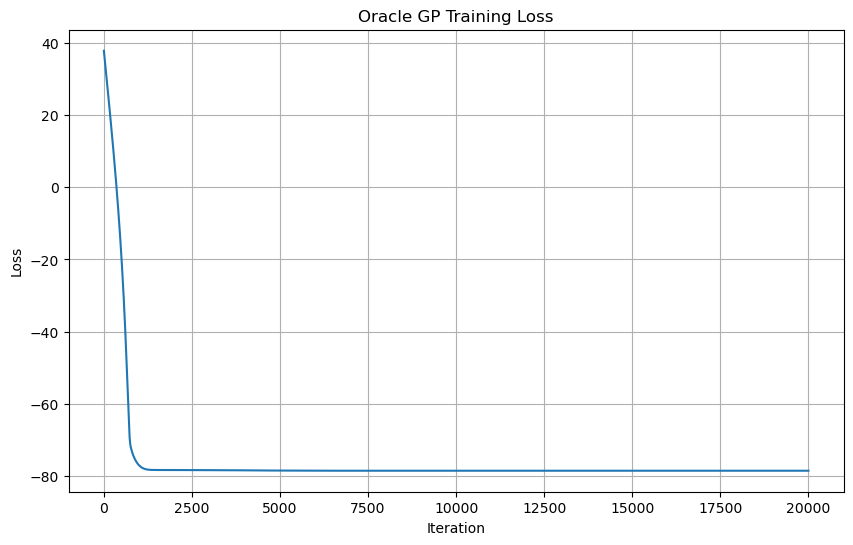

In [11]:
import matplotlib.pyplot as plt

# Extract loss history from the optimizer state
# Since we didn't store losses during training, we'll re-run a quick training loop
# to capture the loss values
coords_orig = coords_perm_data["coords_orig"]
X_orig = coords_perm_data["X_orig"]
Y_orig = coords_perm_data["Y_orig"]

losses = []
param_history = []
gp_oracle_temp = GPModel().to(device)
opt_gp_temp = optim.AdamW(gp_oracle_temp.parameters(), lr=0.001, weight_decay=0.01)

for _ in range(20000):
    opt_gp_temp.zero_grad()
    loss = gp_oracle_temp(coords_orig, X_orig, Y_orig)
    loss.backward()
    opt_gp_temp.step()
    losses.append(loss.item())
    
    # Store parameter updates
    with torch.no_grad():
        gp_oracle_temp.sigmasq.clamp_(min=1e-6)
        gp_oracle_temp.phi.clamp_(min=1e-6)
        gp_oracle_temp.tausq.clamp_(min=1e-6)
        
        param_history.append({
            "nu": float(gp_oracle_temp.nu.item()),
            "phi": float(gp_oracle_temp.phi.item()),
            "sigmasq": float(gp_oracle_temp.sigmasq.item()),
            "tausq": float(gp_oracle_temp.tausq.item()),
            "beta": float(gp_oracle_temp.beta.item()),
        })

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Oracle GP Training Loss')
plt.grid(True)
plt.show()

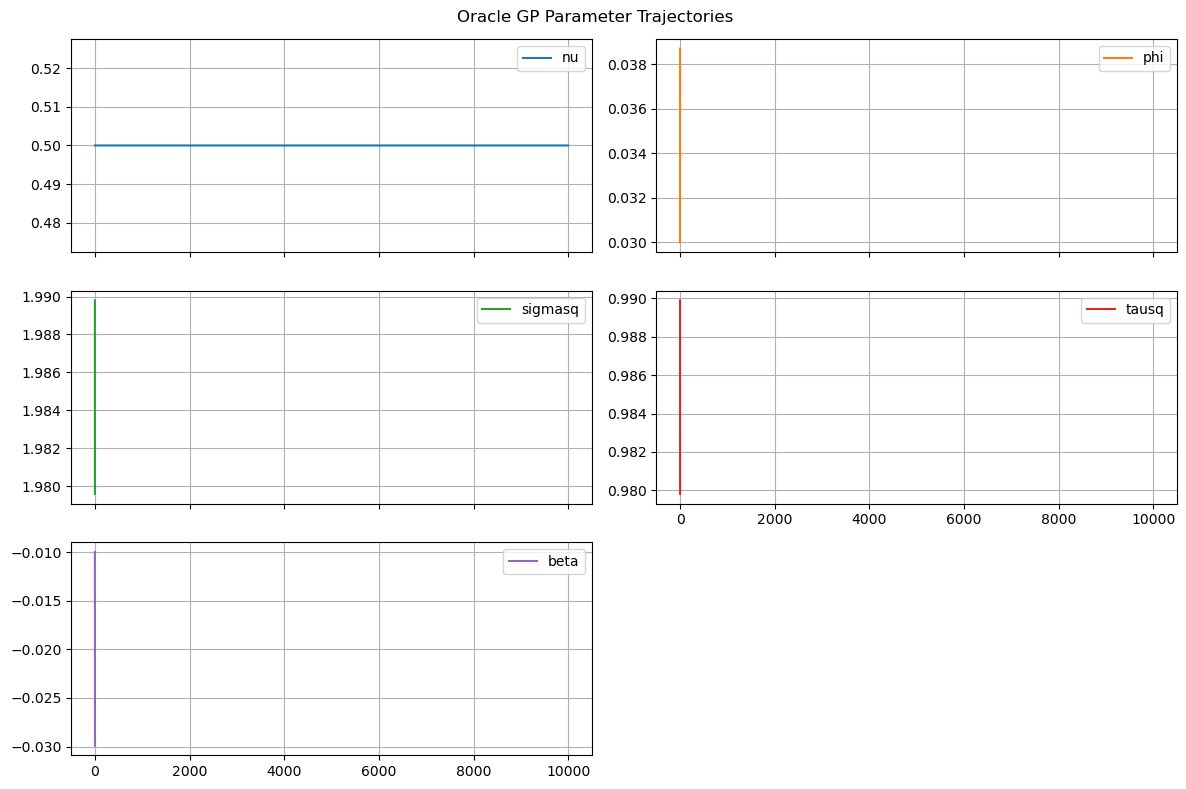

In [5]:
param_history_df = pd.DataFrame(param_history)
param_history_df.plot(figsize=(12, 8), subplots=True, layout=(3,2), sharex=True, grid=True, title='Oracle GP Parameter Trajectories')
plt.tight_layout()
plt.show()


In [ ]:

# -----------------------------
# STEP 5: Compare results
# -----------------------------
print("\n=== Oracle GP (original data) ===")
print(oracle_params)

print("\n=== Areal GP (permuted data) ===")
print(areal_results)

print("\n=== VI (unlinked) taus tried ===")
print(vi_results["taus"])
# Detailed VI output: vi_results["by_tau"][0.3], etc.
